In [1]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json


folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index"


In [2]:

# Open and read the JSON file
with open("best_models_grid_search.json", "r") as json_file:
    output_dict = json.load(json_file)

# Print the contents (optional)
# for dataset, indices in output_dict.items():
#     print(f"Dataset: {dataset}")
#     for index, model in indices.items():
#         print(f"  Index: {index}, Best Model: {model}")

### Parameters

In [3]:
# baselines = ['bmtree', 'kdtree', 'ketree_greddy', 'qdtree', 'r_star_tree', 'rankspace_zorder', 'rlrtree', 'rtree', 'zorder']
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"

# baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
#                    'kdtree':'',
#                    'platon':'',
#                    'zmindex':'',
#                    # 'waffle':'',
#                    'kdtree_greedy':'',
#                    'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_200',
#                    'r_star_tree':'_rstar',
#                    'rankspace_zorder':'_bits_32',
#                    'rlrtree':'_rlrtree_epoch_10_sample_10000',
#                    'rtree':'_quadratic',
#                    'zorder':'_bits_32'}

with open("best_models_grid_search.json", "r") as json_file:
    output_dict = json.load(json_file)


baseline_suffix = {'bmtree':'_bits_32_depth_12_sample_10000', 
                   'kdtree':'',
                   'platon':'',
                   'zmindex':'_bits_32',
                   'waffle':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_400',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_8_sample_80000',
                   'rtree':'_quadratic',
                   'zorder':'_bits_32'}

data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']
baselines = ['rtree', 'r_star_tree',  'kdtree', 'kdtree_greedy','zorder', 'rankspace_zorder']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'order', 'rankspace_zorder', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'kdtree', 'kdtree_greedy', 'waffle', 'qdtree', 'zorder', 'rankspace_zorder', 'zmindex', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zmindex', 'bmtree', 'kdtree', 'kdtree_greedy', 'qdtree']
display_baselines = ['RT', 'RST', 'KD', 'KDG','ZR', 'ZRR']
display_baselines = ['RT', 'RST', 'RLR', 'KD', 'KDG', 'QD','ZR', 'ZRR', 'BMT']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']
display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree', 'Kd-tree', 'Waffle', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree']
display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree']

In [4]:
# 1 
# default_range_name = "_{data_name}_range_1000_2_normal_1_0.001x0.001"
real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

data_name = "us_100000000"
dis_data_name = "US"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

query_range_r1 = [0.00025, 0.0005, 0.001, 0.002, 0.004]
query_range_r2 = [0.004, 0.002, 0.001, 0.0005, 0.00025]

# display_query_ranges = ["0.01%","0.05%","0.1%","0.5%","1%"]
display_query_ranges = ["1/16", "1/4", "1", "4", "16"]

data_name = "us_100000000"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

display_query_ranges = ["0.01%","0.05%","0.1%","0.5%","1%"]

data_name = "us_100000000"
k=25
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

data_name = "us_100000000"
ks=[1, 5, 25, 125, 625]
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

### Read heavy

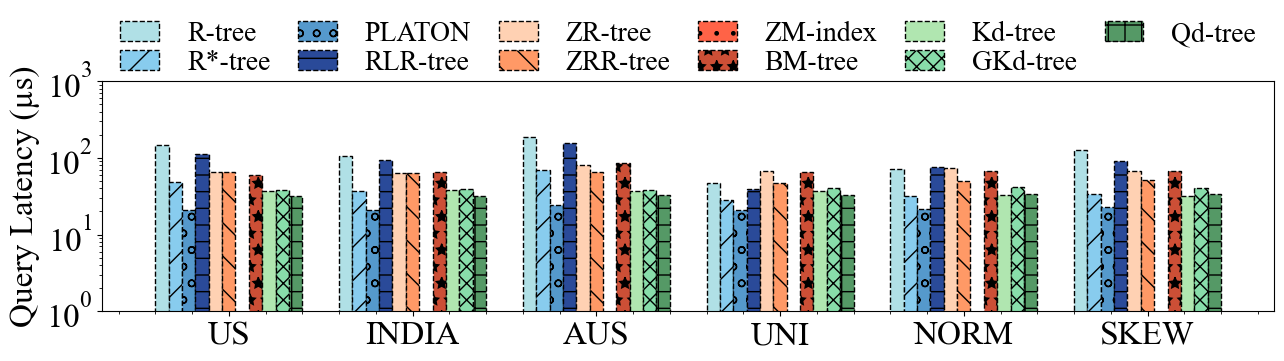

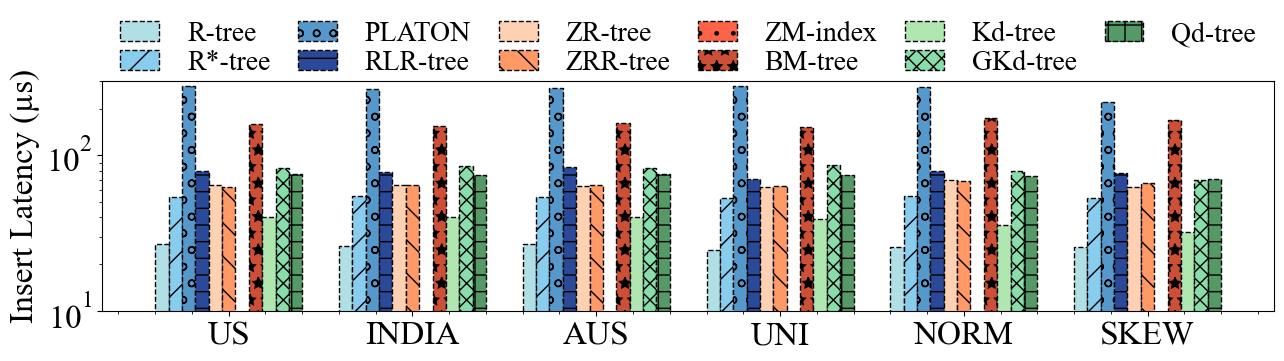

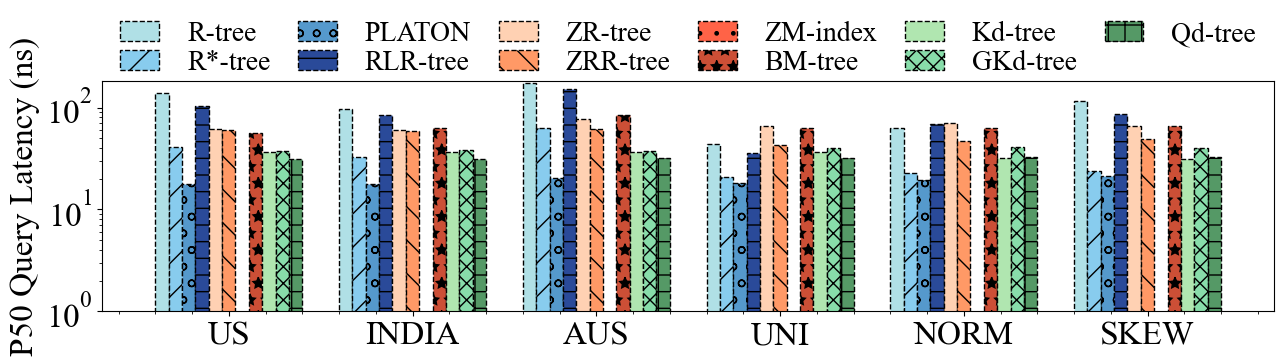

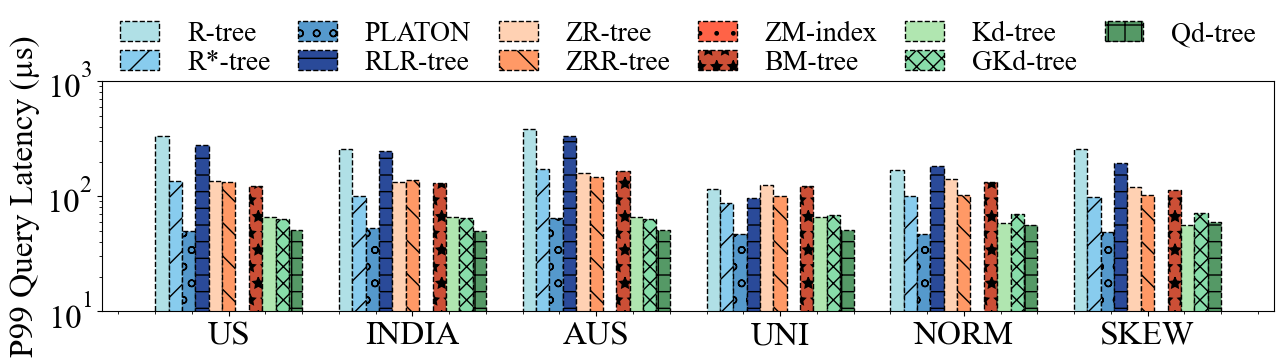

In [10]:
# 1 
synthetic_insert_point_name = "insert_point_10000000_{data_name}_2_uniform_1"
insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_2_18{suffix}.txt"
real_insert_point_name = "{data_name}_insert_point_10000000_2_uniform_1"
default_range_name = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"

insert_result = []
query_result = []

P99 = []
P50 = []


P99_insert = []
P50_insert = []


splits = []
adjustments = []
reads = []
writes = []


for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_query_results = []
    dataset_insert_results = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_P50_insert = []
    dataset_P99_insert = []
    dataset_splits = []
    dataset_adjustments = []
    dataset_reads = []
    dataset_writes = []
    for i, data_name in enumerate(data_names_write):  

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            
        if data_name.startswith("data"):
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name) 
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            insert_point_name=real_insert_point_name.format(data_name=data_name) 
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
            
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)

        dataset_query_results.append(float(tree_property.QueryMean / 1000))
        dataset_insert_results.append(float(tree_property.InsertMean / 1000))
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_reads.append(tree_property.Reads)
        dataset_writes.append(tree_property.Writes)
        dataset_splits.append(tree_property.Splits * 1.0 / 100000)
        dataset_adjustments.append(tree_property.Adjustments)
        
    query_result.append(dataset_query_results) 
    insert_result.append(dataset_insert_results) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    reads.append(dataset_reads)
    writes.append(dataset_writes)
    splits.append(dataset_splits)
    adjustments.append(dataset_adjustments)

plot_hist(display_data_names, display_baselines, query_result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_query_time.pdf", "../figs/exp_sigmod/read_heavy_query_time.png"], bottom=1, top=1e3, legend_location="top")

plot_hist(display_data_names, display_baselines, insert_result, y_label="Insert Latency (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_insert_time.pdf", "../figs/exp_sigmod/read_heavy_insert_time.png"], bottom=10, top=300, legend_location="top")

plot_hist(display_data_names, display_baselines, P50, y_label="P50 Query Latency (ns)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_query_time_P50.pdf", "../figs/exp_sigmod/read_heavy_query_time_P50.png"], legend_location="top")

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/read_heavy_query_time_P99.pdf", "../figs/exp_sigmod/read_heavy_query_time_P99.png"], bottom=1e1, top=1e3, legend_location="top")

# plot_hist(display_data_names, display_baselines, P50, y_label="P50 Insert Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/exp_sigmod/read_heavy_insert_time_P50.pdf", "../figs/exp_sigmod/read_heavy_insert_time_P50.png"], legend_location="top")

# plot_hist(display_data_names, display_baselines, P99, y_label="P99 Insert Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/exp_sigmod/read_heavy_insert_time_P99.pdf", "../figs/exp_sigmod/read_heavy_insert_time_P99.png"], bottom=1e1, top=2*1e4, legend_location="top")

# plot_hist(display_data_names, display_baselines, splits, y_label="Split Ratio (%)", output_file_paths=
#           [folder + "/figs/read_heavy_splits.pdf", "../figs/exp/read_heavy_splits.png"], top=0.5)


### Write only

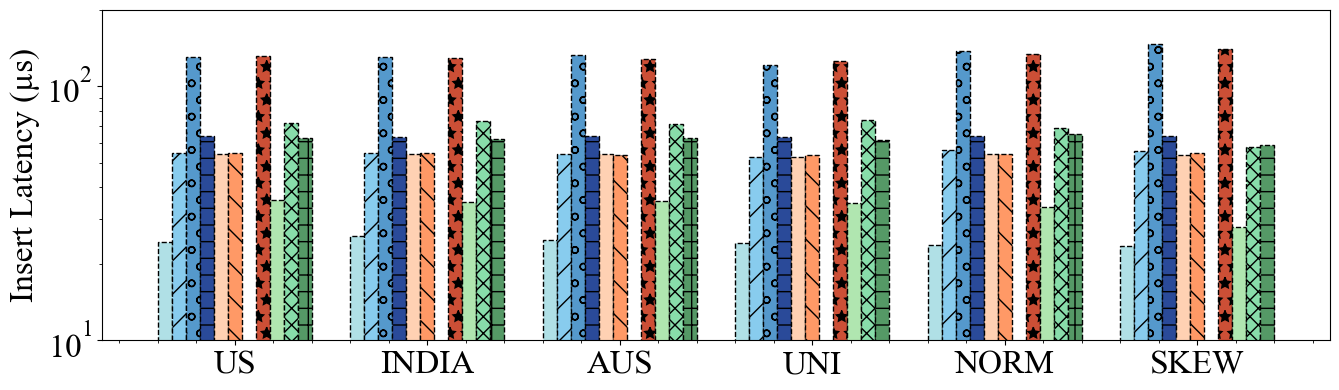

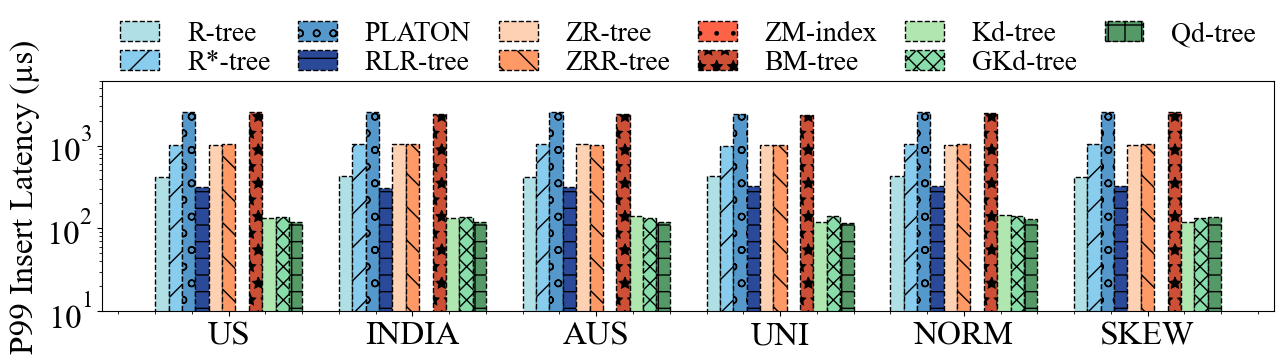

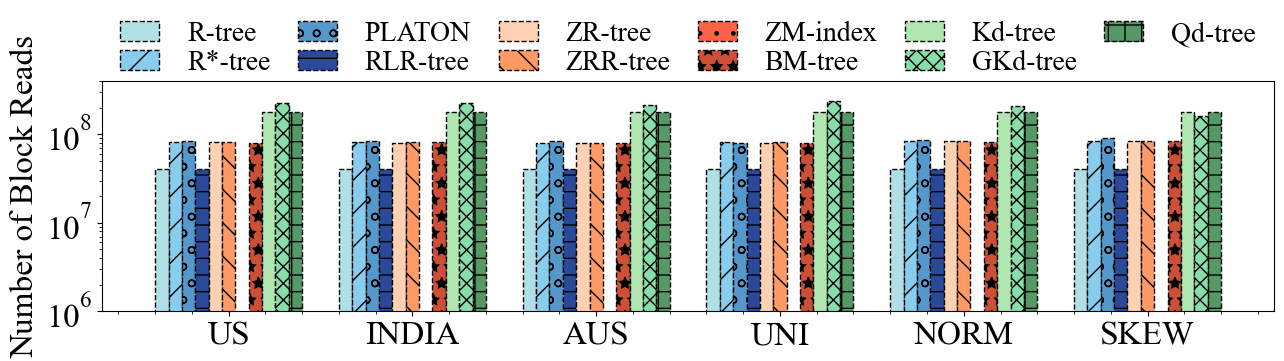

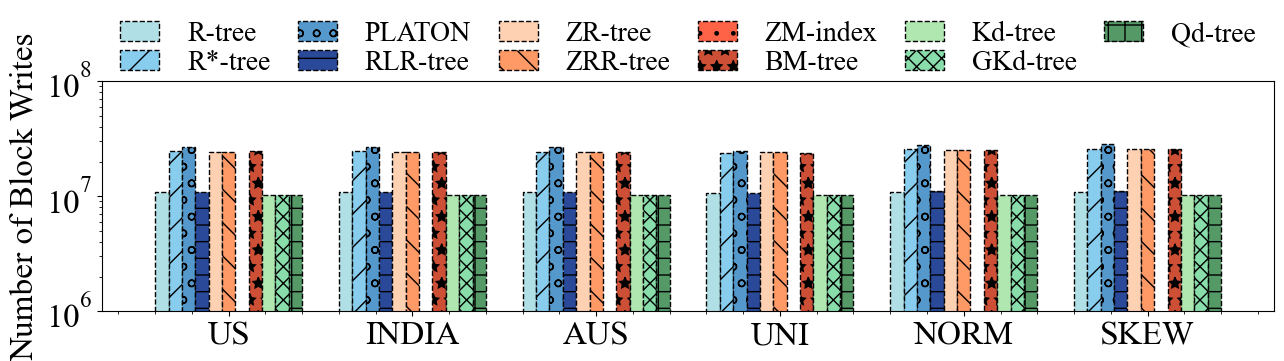

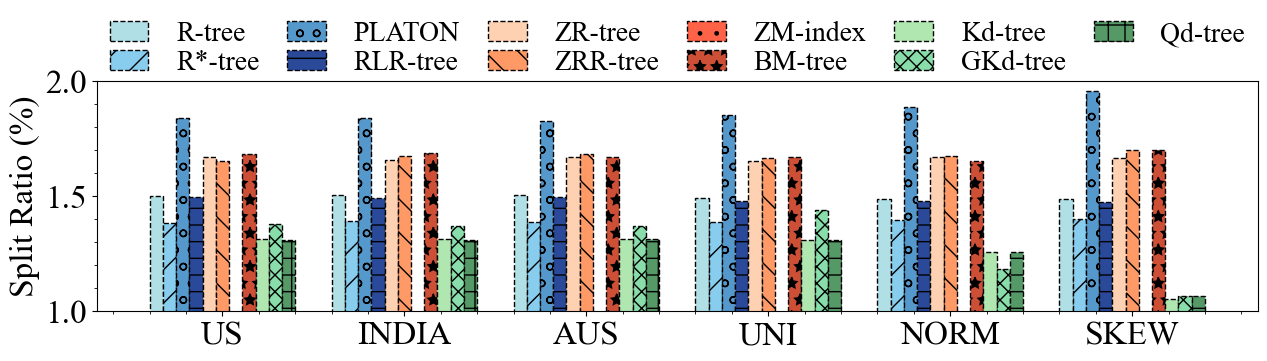

In [6]:
# 1 
data_name = "OSM_10000"
real_insert_point_name = "{data_name}_insert_point_10000000_2_uniform_1"
default_range_name = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
result = []
IO = []
result_num = []

P99 = []
P50 = []

splits = []
adjustments = []
reads = []
writes = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_splits = []
    dataset_adjustments = []
    dataset_reads = []
    dataset_writes = []
    for i, data_name in enumerate(data_names_write):  

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]

        if data_name.startswith("data"):
            insert_name = synthetic_insert_name
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            insert_name=real_insert_name.format(data_name=data_name) 
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name,
            insert_name=insert_name,
            default_range_name=default_range_name,
            suffix=suffix
        )

        # print(insert_result_path.format(name=baseline), insert_result_name)
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.InsertMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        dataset_IO.append(tree_property.IndexIo + tree_property.LeafIo)
        dataset_P50.append(tree_property.InsertP50 / 1000)
        dataset_P99.append(tree_property.InsertP99 / 1000)
        dataset_reads.append(tree_property.Reads)
        dataset_writes.append(tree_property.Writes)
        dataset_splits.append(tree_property.Splits * 1.0 / 100000)
        dataset_adjustments.append(tree_property.Adjustments)

    result.append(dataset_results)
    result_num.append(dataset_result_num)
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    reads.append(dataset_reads)
    writes.append(dataset_writes)
    splits.append(dataset_splits)
    adjustments.append(dataset_adjustments)

plot_hist(display_data_names, display_baselines, result, y_label="Insert Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_only.pdf", "../figs/exp_sigmod/write_only.png"], bottom=1e1, top=2*1e2, legend_location="top")

# plot_hist(display_data_names, display_baselines, P50, y_label="P50 Insert Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/write_only_P50.pdf", "../figs/exp/write_only_P50.png"])

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Insert Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_only_P99.pdf", "../figs/exp_sigmod/write_only_P99.png"], bottom=1e1, top=6*1e3, legend_location="top")

plot_hist(display_data_names, display_baselines, reads, y_label="Number of Block Reads", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_only_reads.pdf", "../figs/exp_sigmod/write_only_reads.png"], bottom=1e6, top=4*1e8, legend_location="top")

plot_hist(display_data_names, display_baselines, writes, y_label="Number of Block Writes", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_only_writes.pdf", "../figs/exp_sigmod/write_only_writes.png"], bottom=1e6, top=1e8, legend_location="top")

plot_hist(display_data_names, display_baselines, splits, y_label="Split Ratio (%)", output_file_paths=
          [folder + "/exp_sigmod/write_only_splits.pdf", "../figs/exp_sigmod/write_only_splits.png"], top=2.0, legend_location="top")

# plot_hist(display_data_names, display_baselines, adjustments, y_label="# of adjustments", is_log=True, output_file_paths=
#           [folder + "/figs/write_only_adjustments.pdf", "../figs/exp/write_only_adjustments.png"])


### Balanced

In [7]:
# # 1 
# data_name = "us_10000000"
# default_range_name = "_{data_name}_range_1000_2_uniform_1_0.001x0.001_2_uniform_1"
# insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_10_10{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

# insert_result = []
# query_result = []

# P99_query = []
# P50_query = []
# P99_insert = []
# P50_insert = []


# splits = []
# adjustments = []
# reads = []
# writes = []


# for baseline in baselines:
#     suffix = baseline_suffix[baseline]
#     dataset_query_results = []
#     dataset_insert_results = []
#     dataset_P50_Q = []
#     dataset_P99_Q = []
#     dataset_P50_I = []
#     dataset_P99_I = []
#     dataset_splits = []
#     dataset_adjustments = []
#     dataset_reads = []
#     dataset_writes = []
#     for data_name in data_names_write:  

#         if data_name.startswith("data"):
#             insert_point_name = synthetic_insert_point_name.format(data_name=data_name) 
#             default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
#         else:
#             insert_point_name=real_insert_point_name.format(data_name=data_name) 
#             default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
            
#         insert_point_result_name = insert_point_result_name_pattern.format(
#             data_name=data_name,
#             insert_point_name=insert_point_name,
#             default_range_name=default_range_name,
#             suffix=suffix
#         )
#         res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
#         tree_property = parse_rtree_properties(res)

#         dataset_query_results.append(float(tree_property.QueryMean / 1000))
#         dataset_insert_results.append(float(tree_property.InsertMean / 1000))
#         dataset_P50_Q.append(tree_property.QueryP50 / 1000)
#         dataset_P99_Q.append(tree_property.QueryP99 / 1000)
#         dataset_P50_I.append(tree_property.InsertP50 / 1000)
#         dataset_P99_I.append(tree_property.InsertP99 / 1000)
#         dataset_reads.append(tree_property.Reads)
#         dataset_writes.append(tree_property.Writes)
#         dataset_splits.append(tree_property.Splits * 1.0 / 100000)
#         dataset_adjustments.append(tree_property.Adjustments)
        
#     query_result.append(dataset_query_results) 
#     insert_result.append(dataset_insert_results) 
#     P50_query.append(dataset_P50_Q)
#     P99_query.append(dataset_P99_Q)
#     P50_insert.append(dataset_P50_I)
#     P99_insert.append(dataset_P99_I)
#     reads.append(dataset_reads)
#     writes.append(dataset_writes)
#     splits.append(dataset_splits)
#     adjustments.append(dataset_adjustments)

# plot_hist(display_data_names, display_baselines, query_result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/balanced_query_time.pdf", "../figs/exp/balanced_query_time.png"], bottom=1, top=2*1e3)
# plot_hist(display_data_names, display_baselines, insert_result, y_label="Insert Latency (µs)", is_legend=False, is_log=True, output_file_paths=
#           [folder + "/figs/balanced_insert_time.pdf", "../figs/exp/balanced_insert_time.png"], bottom=1e1, top=1e2)

# plot_hist(display_data_names, display_baselines, P50_query, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/balanced_query_time_P50.pdf", "../figs/exp/balanced_query_P50.png"], bottom=1, top=1e3)

# plot_hist(display_data_names, display_baselines, P99_query, y_label="P99 Query Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/balanced_query_time_P99.pdf", "../figs/exp/balanced_query_time_P99.png"], bottom=1e1, top=2*1e4)

# plot_hist(display_data_names, display_baselines, P50_insert, y_label="P50 Insert Latency (µs)", is_log=False, output_file_paths=
#           [folder + "/figs/balanced_insert_time_P50.pdf", "../figs/exp/balanced_insert_time_P50.png"], bottom=1e1, top=3*1e1)

# plot_hist(display_data_names, display_baselines, P99_insert, y_label="P99 Insert Latency (µs)", is_log=True, output_file_paths=
#           [folder + "/figs/balanced_insert_time_P99.pdf", "../figs/exp/balanced_insert_time_P99.png"], bottom=1e1, top=2*1e3)

# plot_hist(display_data_names, display_baselines, splits, y_label="Split Ratio (%)", output_file_paths=
#           [folder + "/figs/balanced_splits.pdf", "../figs/exp/balanced_splits.png"], bottom=0, top=1.5)

### Write heavy

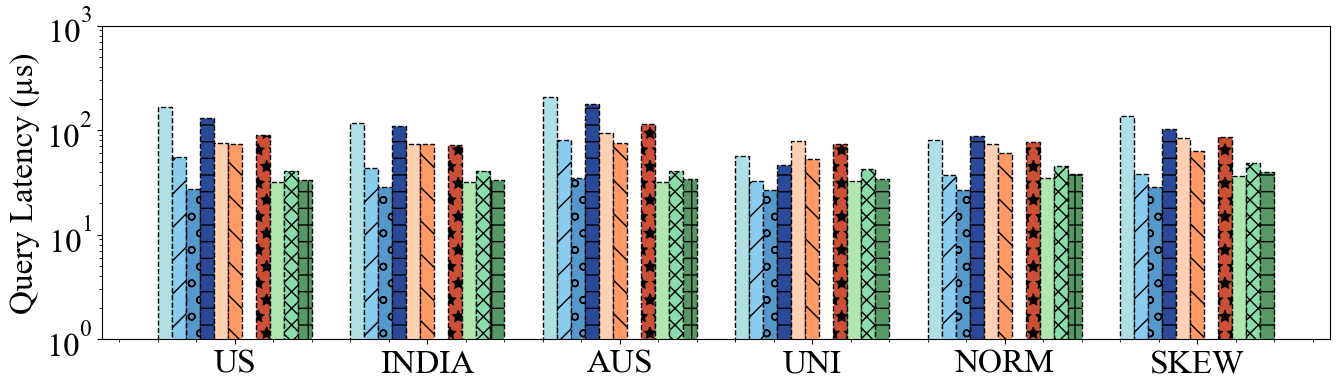

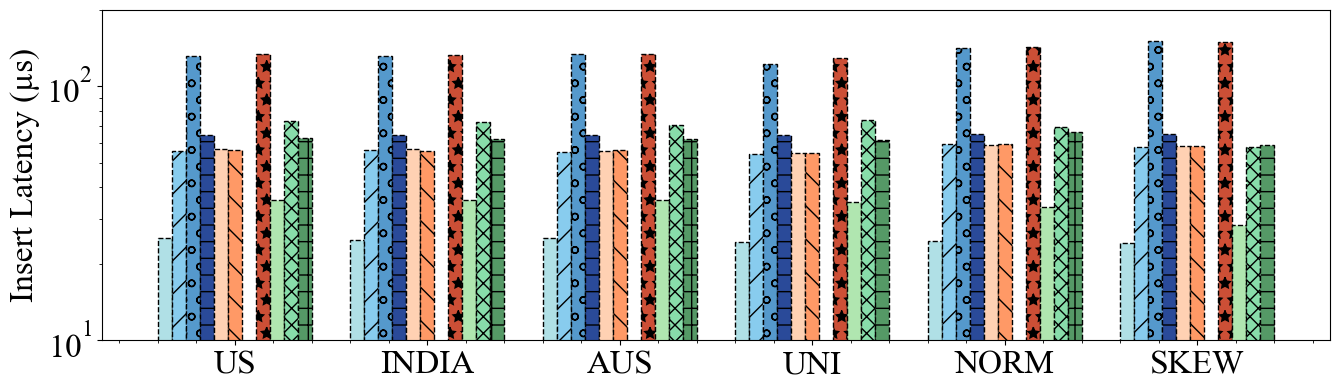

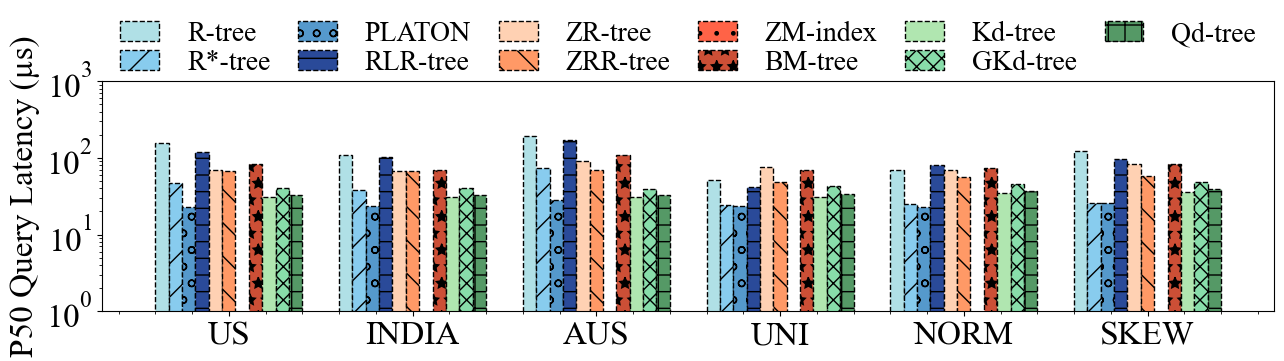

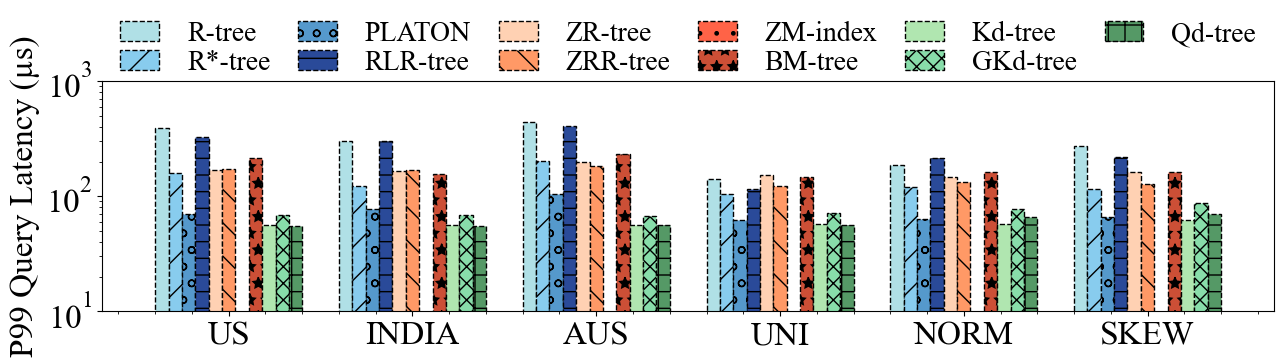

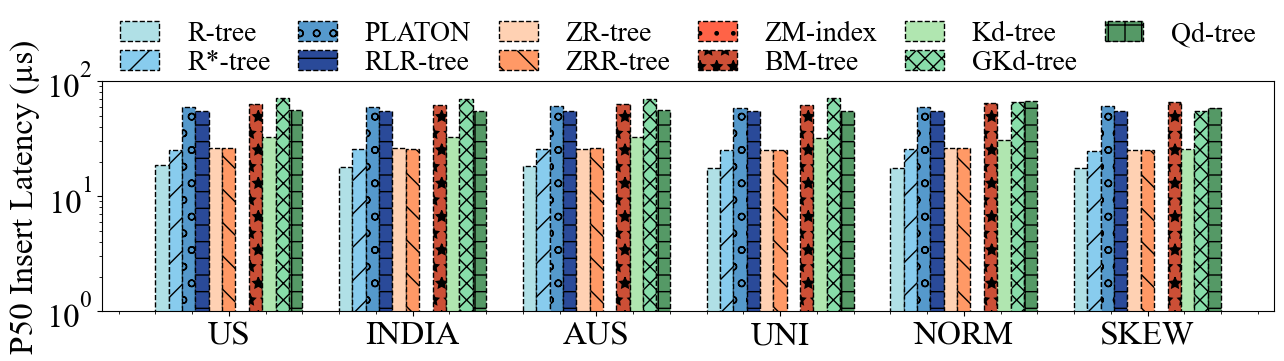

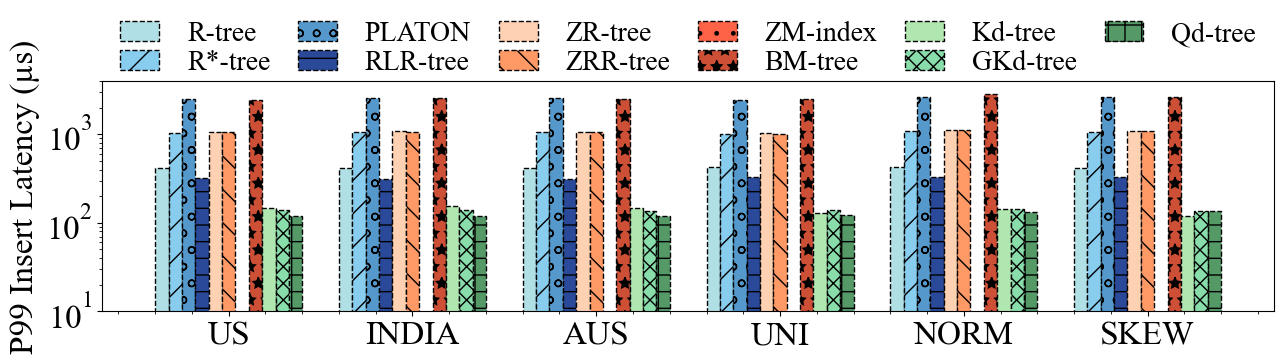

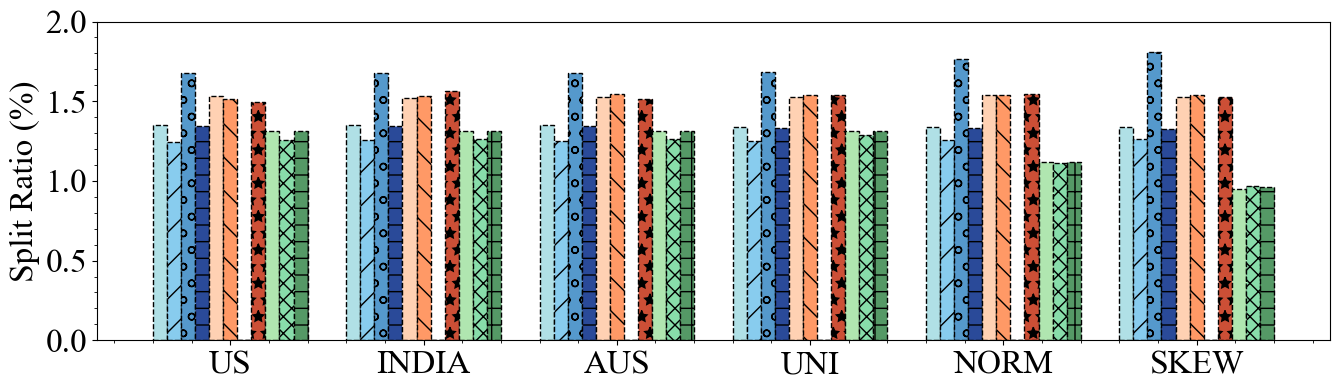

In [11]:
# 1 
insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_18_2{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

insert_result = []
query_result = []


P99_query = []
P50_query = []
P99_insert = []
P50_insert = []

splits = []
adjustments = []
reads = []
writes = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_query_results = []
    dataset_insert_results = []
    dataset_P50_Q = []
    dataset_P99_Q = []
    dataset_P50_I = []
    dataset_P99_I = []
    dataset_splits = []
    dataset_adjustments = []
    dataset_reads = []
    dataset_writes = []
    for i, data_name in enumerate(data_names_write):  

        if baseline in output_dict[display_data_names[i]].keys():
            suffix = output_dict[display_data_names[i]][baseline]
            
        if data_name.startswith("data"):
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name) 
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            insert_point_name=real_insert_point_name.format(data_name=data_name) 
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        
            
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )

        # print(insert_point_result_path.format(name=baseline), insert_point_result_name)
        
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)

        dataset_query_results.append(float(tree_property.QueryMean / 1000))
        dataset_insert_results.append(float(tree_property.InsertMean / 1000))
        dataset_P50_Q.append(tree_property.QueryP50 / 1000)
        dataset_P99_Q.append(tree_property.QueryP99 / 1000)
        dataset_P50_I.append(tree_property.InsertP50 / 1000)
        dataset_P99_I.append(tree_property.InsertP99 / 1000)
        dataset_reads.append(tree_property.Reads)
        dataset_writes.append(tree_property.Writes)
        dataset_splits.append(tree_property.Splits * 1.0 / 100000) # 1/100000 = 1/10000000 * 100
        dataset_adjustments.append(tree_property.Adjustments)
        
    query_result.append(dataset_query_results) 
    insert_result.append(dataset_insert_results) 
    P50_query.append(dataset_P50_Q)
    P99_query.append(dataset_P99_Q)
    P50_insert.append(dataset_P50_I)
    P99_insert.append(dataset_P99_I)
    reads.append(dataset_reads)
    writes.append(dataset_writes)
    splits.append(dataset_splits)
    adjustments.append(dataset_adjustments)

plot_hist(display_data_names, display_baselines, query_result, y_label="Query Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_query_time.pdf", "../figs/exp_sigmod/write_heavy_query_time.png"], bottom=1, top=1e3, legend_location="top")

plot_hist(display_data_names, display_baselines, insert_result, y_label="Insert Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_insert_time.pdf", "../figs/exp_sigmod/write_heavy_insert_time.png"], bottom=1e1, top=200, legend_location="top")

plot_hist(display_data_names, display_baselines, P50_query, y_label="P50 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_query_time_P50.pdf", "../figs/exp_sigmod/write_heavy_query_time_P50.png"], bottom=1, top=1e3, legend_location="top")

plot_hist(display_data_names, display_baselines, P99_query, y_label="P99 Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_query_time_P99.pdf", "../figs/exp_sigmod/write_heavy_query_time_P99.png"], bottom=1e1, top=1e3, legend_location="top")

plot_hist(display_data_names, display_baselines, P50_insert, y_label="P50 Insert Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_insert_time_P50.pdf", "../figs/exp_sigmod/write_heavy_insert_time_P50.png"], bottom=1, top=1e2, legend_location="top")

plot_hist(display_data_names, display_baselines, P99_insert, y_label="P99 Insert Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_insert_time_P99.pdf", "../figs/exp_sigmod/write_heavy_insert_time_P99.png"], bottom=1e1, top=4*1e3, legend_location="top")

plot_hist(display_data_names, display_baselines, splits, y_label="Split Ratio (%)", is_legend=False, output_file_paths=
          [folder + "/exp_sigmod/write_heavy_splits.pdf", "../figs/exp_sigmod/write_heavy_splits.png"], bottom=0, top=2.0, legend_location="top")